<a href="https://colab.research.google.com/github/RENSHUZHE/HKU-DQMC/blob/main/DQMC_Part_1_Prerequisite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import matplotlib.pyplot as plt

#DQMC Note 1: Prerequsite

## Monte Carlo

The Monte Carlo method is a computational technique that uses random sampling to estimate numerical results and solve complex mathematical problems.

### Monte Carlo by directly sampling

The directly sampling method can be beautifully illustrated by a hypothetical game played by children in [Monte Carlo, Monaco](https://en.wikipedia.org/wiki/Monte_Carlo), the home of the famous casino that gave the technique its name. In this game, children randomly toss small pebbles into a square and calculate the ratio of stones that land inside an inscribed circle to estimate its relative area. Actually there is a very interesting story behind the Casino and the opium war and Hong Kong, that we can discuss during the class.

Total Samples: 20,000
Points Inside Circle: 15,770
Estimated Pi: 3.154000
Actual Pi:    3.141593
Error:        0.012407


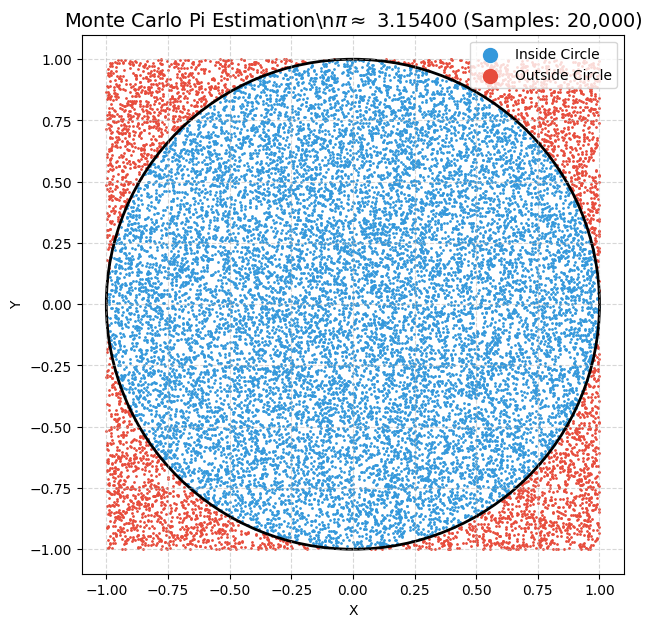

In [18]:
def estimate_pi(num_samples):
    # 1. Generate random (x, y) coordinates between -1 and 1
    # This represents throwing pebbles randomly into a 2x2 square
    points = np.random.uniform(-1, 1, size=(num_samples, 2))
    x, y = points[:, 0], points[:, 1]

    # 2. Check if the points fall inside the inscribed unit circle (x^2 + y^2 <= 1)
    distance_from_origin = x**2 + y**2
    inside_circle = distance_from_origin <= 1

    # 3. Calculate Pi estimate: 4 * (points inside / total points)
    num_inside = np.sum(inside_circle)
    pi_estimate = 4 * num_inside / num_samples

    print(f"Total Samples: {num_samples:,}")
    print(f"Points Inside Circle: {num_inside:,}")
    print(f"Estimated Pi: {pi_estimate:.6f}")
    print(f"Actual Pi:    {np.pi:.6f}")
    print(f"Error:        {abs(pi_estimate - np.pi):.6f}")

    # 4. Visualise the simulation
    plt.figure(figsize=(7, 7))

    # Plot points inside the circle in blue, outside in red
    plt.scatter(x[inside_circle], y[inside_circle], color='#3498db', s=1, label='Inside Circle')
    plt.scatter(x[~inside_circle], y[~inside_circle], color='#e74c3c', s=1, label='Outside Circle')

    # Draw the boundary circle line
    circle = plt.Circle((0, 0), 1, color='black', fill=False, linewidth=2)
    plt.gca().add_patch(circle)

    plt.title(fr"Monte Carlo Pi Estimation\n$\pi \approx$ {pi_estimate:.5f} (Samples: {num_samples:,})", fontsize=14)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)
    plt.legend(loc='upper right', markerscale=10)
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.show()

# Run the simulation
estimate_pi(num_samples=20000)

## Markov Chain Monte Carlo (MCMC)

Now imagine the same game, but played by adults. For them, the playground is huge (perhaps 20 metres by 20 metres), and it is impossible to throw a pebble far enough to cover the entire square. Therefore, they change their strategy.

Now, wherever they throw the pebble, they walk to that landing place, point in a random direction, and throw again. In this process, each throw is followed by the next and is no longer completely independent of the last throw. If they ever throw a pebble outside the square, they must fetch it, place it exactly on the spot of their previous throw, and continue from there.

Lastly, notice that the probability distribution of the next throw depends entirely on the adult's current position. It is completely independent of their past throws or how they arrived at that spot. This **'memoryless'** dependence on the present state is precisely what defines this process as a **Markov chain**.

<>:61: SyntaxWarning: invalid escape sequence '\p'
<>:61: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_18973/2261363374.py:61: SyntaxWarning: invalid escape sequence '\p'
  plt.title(f"Markov Chain Pi Estimation\n$\pi \\approx$ {pi_estimate:.5f}", fontsize=14)


Total Steps:   100,000
Step Size (δ): 0.3
Estimated Pi:  3.145480
Actual Pi:     3.141593
Error:         0.003887


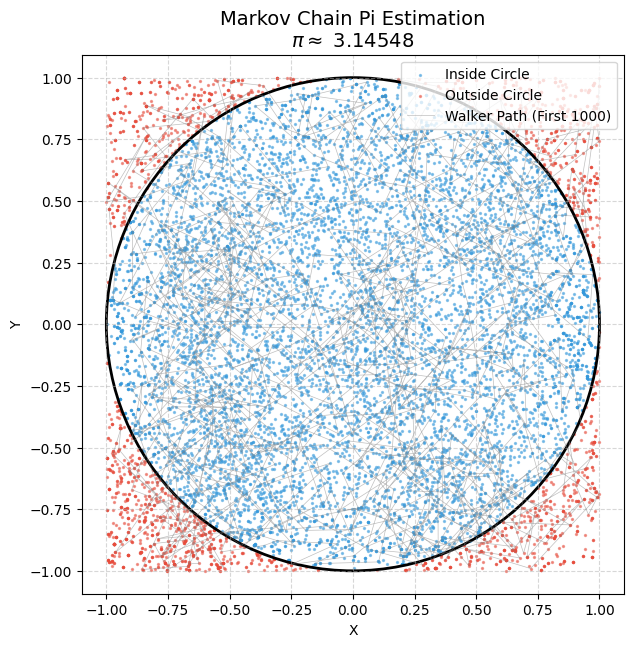

In [ ]:
def markov_pi(num_samples=100000, delta=0.01):
    # 1. Initialise variables exactly as in the pseudocode
    n_hits = 0
    x, y = 1.0, 1.0  # Starting exactly at the top-right corner

    # Arrays to store the path for visualisation
    x_history = np.zeros(num_samples)
    y_history = np.zeros(num_samples)

    # 2. The Markov Chain loop
    for i in range(num_samples):
        # Propose a random step within the throwing range (-delta to delta)
        delta_x = np.random.uniform(-delta, delta)
        delta_y = np.random.uniform(-delta, delta)

        # The referee checks if the new position is still inside the 2x2 square
        if abs(x + delta_x) < 1.0 and abs(y + delta_y) < 1.0:
            x = x + delta_x
            y = y + delta_y
        # If the move is rejected, x and y remain the same, and the adult stays put

        # Record the current position for our plot
        x_history[i] = x
        y_history[i] = y

        # 3. Check if the current position is inside the inscribed circle
        if x**2 + y**2 < 1.0:
            n_hits += 1

    # Calculate Pi
    pi_estimate = 4 * n_hits / num_samples

    print(f"Total Steps:   {num_samples:,}")
    print(f"Step Size (δ): {delta}")
    print(f"Estimated Pi:  {pi_estimate:.6f}")
    print(f"Actual Pi:     {np.pi:.6f}")
    print(f"Error:         {abs(pi_estimate - np.pi):.6f}")

    # 4. Visualise the Markov Chain
    plt.figure(figsize=(7, 7))

    # Check which points in our history landed inside the circle
    distances = x_history**2 + y_history**2
    inside = distances < 1.0

    # Plot the points (using a smaller sample size to prevent the plot from becoming a solid block of colour)
    plot_limit = min(num_samples, 10000)

    plt.scatter(x_history[:plot_limit][inside[:plot_limit]], y_history[:plot_limit][inside[:plot_limit]],
                color='#3498db', s=2, alpha=0.5, label='Inside Circle')
    plt.scatter(x_history[:plot_limit][~inside[:plot_limit]], y_history[:plot_limit][~inside[:plot_limit]],
                color='#e74c3c', s=2, alpha=0.5, label='Outside Circle')

    # Draw a faint line connecting the first 1000 steps to show the "Random Walk" path
    plt.plot(x_history[:1000], y_history[:1000], color='gray', linewidth=0.5, alpha=0.5, label='Walker Path (First 1000)')

    # Draw the boundary circle
    circle = plt.Circle((0, 0), 1, color='black', fill=False, linewidth=2)
    plt.gca().add_patch(circle)

    plt.title(f"Markov Chain Pi Estimation\n$\pi \\approx$ {pi_estimate:.5f}", fontsize=14)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.axis("equal")
    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.show()

# Run the simulation (feel free to change the delta value to see how it affects the chain)
markov_pi(num_samples=100000, delta=0.3)

$\delta=0.3$ is an adjustable parameter. Try adjust it and see what happens.  

This is the adult's throwing range.
If you make $\delta$ very small (like 0.01), the algorithm takes tiny steps and explores the space very slowly, meaning you need millions of samples to get a good estimate.

If you make $\delta$ very large (like 2.0), almost every throw hits the boundary and gets rejected, stalling the chain.

## MCMC: Balance Conditions & Filters
The adults' strategy seems to work well, but it introduces a fundamental problem. We know direct sampling works because it relies on perfectly uniform sampling (*a concept often take for granted; the algorithm for generating a uniform distribution is fascinating, refer to Krauth's book for more context*).

However, **how can we guarantee that the adults' random walk strategy actually results in a uniform distribution of pebbles**? What if there is a strong wind, or the ground is uneven?

You can likely imagine a practical solution to these realistic conditions. An east wind makes it artificially easy for pebbles to travel west. To counter this, the player need to apply a rule to "filter" their throws, deliberately rejecting some of the easy eastern throws to maintain an even spread across the playground.

This brings us to our theme below. We will formalise these intuitive concepts using mathematical language. We will introduce the **Balance Condition** *(the mathematical requirement to ensure the final distribution remains uniform)* and **Filters** *(the acceptance rules applied to the throwing pattern to ensure the Balance Condition is satisfied)*.

### Global Balance Condition
Let us introduce some mathematical machinery to tackle this problem. We want to study how the probability distribution $\pi_t(x)$ evolves in time. In the pebble game discussed earlier, we can choose the initial distribution to be $\pi_{t=0}(x) = \delta(0,0)$, representing a starting point at $(0,0)$ *(can be any arbitrary starting location).*

Time evolution is described by the transition matrix $P(x \rightarrow x')$, which is defined as the conditional probability to move from $x$ to $x'$ in one step. This gives us the following discrete Master equation:

$$\pi_t(x) = \sum_{x'} \pi_{t-1}(x') P(x' \rightarrow x)$$
This equation calculates the new state by summing past probabilities multiplied by their transition likelihoods. Due to the conservation of probability, the condition $\sum_{x'} P(x \rightarrow x') = 1$ ensures that probability is never lost.

Now, in most Monte Carlo simulations, we have an intended target sampling distribution $\pi(x)$, such as the uniform distribution in the pebble game.

We hope that after a sufficiently long time $t$, the Markov chain's sampling distribution $\pi_t$ will approach our target distribution $\pi$. When this happens, the master equation becomes:

$$\pi(x) = \sum_{x'} \pi(x') P(x' \rightarrow x)$$

In other words, $\pi$ becomes the steady state of the evolution equation. This requirement is known as the **global balance condition**, and it is necessary for our Markov chain to successfully converge to $\pi$.

While the global balance condition is fundamental, it is quite difficult to work with in practice. Usually, we face the inverse problem: we already know our target distribution $\pi$, and we need to construct a transition matrix $P(x \rightarrow x')$ that will get us there. For this engineering task, the **detailed balance condition** is far more practical:

$$\pi(x) P(x \rightarrow x') = \pi(x') P(x' \rightarrow x)$$

It is easy to prove that detailed balance automatically satisfies global balance, making it a stronger condition. It strictly enforces that the probability flow along the forward path $x \rightarrow x'$ exactly matches the flow along the reversed path $x' \rightarrow x$. Because of this symmetry, Markov chain algorithms that obey detailed balance are known as *reversible*.




### The Metropolis Filter

Using the detailed balance condition, we can motivate the construction of a transition matrix for a given target distribution $\pi(x)$. Let us propose the following relationship:

$$\pi(x) P(x \rightarrow x') \propto \min[\pi(x), \pi(x')] \quad \text{for } x \neq x'$$

The detailed balance condition is automatically satisfied by this construction. By dividing both sides by $\pi(x)$, we arrive at the following proportionality:

$$P^{\text{Met}}(x \rightarrow x') \propto \min\left[1, \frac{\pi(x')}{\pi(x)}\right]$$

This minimum function represents the core logic of the Metropolis algorithm. To replace the proportionality sign with a strict equality, we must factor in the blind proposal generation. This gives us the complete equation for the transition matrix:

$$P^{\text{Met}}(x \rightarrow x') = \mathcal{A}(x \rightarrow x') α(x \rightarrow x')$$

In this exact expression:
* $P^{\text{Met}}(x \rightarrow x')$ is the full transition matrix.
* $\mathcal{A}(x \rightarrow x')$ is the *a priori* probability (the proposal distribution).
* $α(x \rightarrow x')$ is the Metropolis filter (the acceptance probability).

However, in most physical simulations, the *a priori* probability is chosen to be symmetrical, meaning $\mathcal{A}(x \rightarrow x') = \mathcal{A}(x' \rightarrow x)$. Because of this symmetry, the mathematical formulation simplifies beautifully. The acceptance probability, or Metropolis filter, becomes exactly:

$$\alpha(x \rightarrow x') = \min\left[1, \frac{\pi(x')}{\pi(x)}\right]$$


### Monte Carlo Section (old part 1, underconstruction)

For a steady-state distribution $\pi(i)$, we have the detailed balance condition:

$$\pi(i) Q(i, j) \alpha(i, j)=\pi(j) Q(j, i) \alpha(j, i)$$

where $Q(i, j)$ represents the probability of attempting to transition from $i$ to $j$, and $\alpha(i, j)$ is the corresponding acceptance probability. We typically choose:

$$\alpha(i, j)=\min \left\{\frac{\pi(j) Q(j, i)}{\pi(i) Q(i, j)}, 1\right\}$$

In most cases, $Q(i, j)=Q(j,i)$. For example, in the Metropolis algorithm for the classical Ising model, the weight of each configuration is $\propto e^{-\beta E}$, and the acceptance probability is $\min \left\{e^{-\beta \Delta E}, 1\right\}$.

### Statistical Mechanics Section

For classical models, we have the partition function:

$$Z=\sum_{\sigma} e^{-\beta E_{\sigma}}$$

Physical observables:

$$\langle O\rangle=\frac{1}{Z} \sum_{C} O e^{-\beta E_{C}}$$

For quantum systems, the partition function is:

$$Z=\operatorname{Tr}\left\{e^{-\beta H}\right\}$$

Choosing a basis:

$$Z=\sum_{\{\phi\}}\left\langle\{\phi\}\left|e^{-\beta H}\right|\{\phi\}\right\rangle$$

Physical observables:

$$\langle O\rangle=\frac{\operatorname{Tr}\left\{O e^{-\beta H}\right\}}{Z}$$

### Trotter Decomposition

$$\begin{aligned}Z &=\operatorname{Tr}\left[e^{-\beta H}\right] \\&=\operatorname{Tr}\left[(e^{-\Delta \tau H_I} e^{-\Delta \tau H_0})^{L_{\tau}} \right] \\&=\operatorname{Tr}\left[e^{-\Delta \tau H_I} e^{-\Delta \tau H_0} \ldots e^{-\Delta \tau H_I} e^{-\Delta \tau H_0}\right] +\mathcal{O}\left[(\Delta \tau)^{2}\right]\end{aligned}$$

where $L_\tau =\frac{\beta}{\Delta \tau}$

# DQMC Note 2: DQMC Starting with the Hubbard Model
## Why is it called DQMC?

DQMC is mainly used to calculate finite-temperature fermion systems. In the actual operational process, there is only the two-fermion part. Then, for Hamiltonians containing four-fermion interactions like the Hubbard Model, we usually adopt the Hubbard-Stratonovich transformation method, introducing an auxiliary field to decouple it. Then it becomes a two-fermion form, with an additional auxiliary field. (Later we will know that different decoupling methods may lead to the presence or absence of the sign problem).

The reason why DQMC is called Determinantal Monte Carlo is that it converts the calculation of the Trace into calculating the determinant of a matrix. For example, if we want to calculate a Trace in the following form:

$$\operatorname{Tr}\left[e^{-\sum_{i, j} \hat{c}_{i}^{\dagger} A_{i, j} \hat{c}_{j}}\right]=\operatorname{Det}\left[\mathbf{1}+e^{-\mathbf{A}}\right]$$

Where $A_{i, j}$ are the elements of matrix $A$. We can see that the operation of calculating the Trace is converted into calculating the determinant of an identity matrix $\mathbf{1}$ plus the matrix $e^{-\mathbf{A}}$.

There are various ways to prove this, for instance, we can diagonalise the part on the exponent of e, and the Trace is simply the sum over all possibilities for $n_{i}=0,1$:

$$\begin{aligned}&\operatorname{Tr}\left[e^{-\sum_{i, j} \hat{c}_{i}^{\dagger} A_{i, j} \hat{c}_{j}}\right]\\ =&\operatorname{Tr}\left[e^{-\sum_{k} \epsilon(k) \hat{c}_{k}^{\dagger} \hat{c}_{k}}\right]\\ =&\Pi_{k} \operatorname{Tr}\left[e^{-\epsilon(k) \hat{c}_{k}^{\dagger} \hat{c}_{k}}\right]\\ =&\Pi_{k}\left[1+e^{-\epsilon(k)}\right]\end{aligned}$$

The determinant is just the product of eigenvalues, so the above equation obviously holds.

Alternatively, if you feel that having operators on the exponent of e is not direct enough, you can expand it:

$$\exp \left(-c_{k}^{\dagger} \epsilon(k) c_{k}\right)=1-c_{k}^{\dagger} \epsilon(k) c_{k}+\frac{1}{2 !} c_{k}^{\dagger} \epsilon(k) c_{k} c_{k}^{\dagger} \epsilon(k) c_{k}-\frac{1}{3 !} \cdots$$

By further utilising $c_{k}^{\dagger} c_{k}+c_{k} c_{k}^{\dagger}=1$ and $c_{k} c_{k}|\psi\rangle=0$, we have:

$$\begin{aligned}
\exp \left(-c_{k}^{\dagger} \epsilon(k) c_{k}\right) &=1-c_{k}^{\dagger} \epsilon(k) c_{k}+\frac{1}{2 !} c_{k}^{\dagger} \epsilon(k)^{2} c_{k}-\frac{1}{3 !} \cdots \\
&=1+\left[e^{-\epsilon(k)}-1\right] c_{k}^{\dagger} c_{k}
\end{aligned}$$

(Smart students obviously already know that for fermions, $\hat{n}_{k}^{m}=\hat{n}_{k}$...)

And what is important for DQMC is the generalised form of the above equation. For the new form, we can still perform diagonalisation ([PhysRevB.31.4403](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.31.4403)):

$$e^{-\sum_{i, j} c_{i}^{\dagger} A_{i, j} c_{j}} e^{-\sum_{i, j} c_{i}^{\dagger} B_{i, j} c_{j}}=e^{-\sum_{\nu} c_{\nu}^{\dagger} l_{\nu} c_{\nu}}$$

Starting from a single-particle state: $e^{-A} e^{-B}$ acts on $|\psi\rangle=c_{\nu}^{\dagger}|0\rangle$:

$$e^{-\sum_{i, j} c_{i}^{\dagger} A_{i, j} c_{j}} e^{-\sum_{i, j} c_{i}^{\dagger} B_{i, j} c_{j}}|\psi\rangle=\left(e^{-A} e^{-B}\right)_{\nu \nu} c_{\nu}^{\dagger}|0\rangle=e^{-l_{\nu}} c_{\nu}^{\dagger}|0\rangle$$

Considering a many-particle state, for example, a two-particle state $|\phi\rangle=c_{\mu_{1}}^{\dagger} c_{\mu_{2}}^{\dagger}|0\rangle$, we have:

$$\begin{aligned}
e^{-c_{i}^{\dagger} B_{i j} c_{j}}|\phi\rangle &=\prod_{\mu}\left[1+\left(e^{-B_{\mu}}-1\right) c_{\mu}^{\dagger} c_{\mu}\right] c_{\mu_{1}}^{\dagger} c_{\mu_{2}}^{\dagger}|0\rangle \\
&=e^{-B_{\mu_{1}}} e^{-B_{\mu_{2}}} c_{\mu_{1}}^{\dagger} c_{\mu_{2}}^{\dagger}|0\rangle
\end{aligned}$$

Therefore, we have:

$$\operatorname{Tr}\left[e^{-\sum_{i, j} c_{i}^{\dagger} A_{i, j} c_{j}} e^{-\sum_{i, j} c_{i}^{\dagger} B_{i, j} c_{j}}\right]=\operatorname{Det}\left(1+e^{-\mathbf{A}} e^{-\mathbf{B}}\right)$$

For more general cases, the form is self-evident.

## Hubbard Model and Hubbard-Stratonovitch Transformation

We know that for a free fermion system, we can analytically and directly calculate information such as the Matsubara Green's function:

$$G\left(i \omega_{n}\right)=\frac{1}{i \omega_{n}-\left(\epsilon_{k}-\mu\right)}$$

However, for models containing four-fermion interactions like the Hubbard Model, we need a discrete Hubbard-Stratonovitch decomposition, introducing an auxiliary field to carry out Monte Carlo solving.

Historically, this type of DQMC was first used to solve boson-fermion coupling models, also known as the Blankenbecler-Scalapino-Sugar (BSS) algorithm. Later, in 1983, Hirsch proposed the HS transformation for the Hubbard model with on-site Coulomb interactions, that is, by introducing an auxiliary field, decoupling the interaction into the coupling of non-interacting fermions and the auxiliary field, which gradually enabled simple DQMC calculations for interacting fermion systems.

The Hamiltonian of the Hubbard Model is written as:

$$\hat{H}=-t \sum_{\langle i j\rangle \sigma} \hat{c}_{i \sigma}^{\dagger} \hat{c}_{j \sigma}+h.c.+U \sum_{i}\left(\hat{n}_{i \uparrow}-\frac{1}{2}\right)\left(\hat{n}_{i \downarrow}-\frac{1}{2}\right)$$

We usually divide the imaginary time into $M$ slices: $\beta=M \Delta \tau$. Then we perform a Trotter decomposition. The reason for doing this is because $\hat{H}_{0}=-t \sum_{\langle i j\rangle \sigma} \hat{c}_{i \sigma}^{\dagger} \hat{c}_{j \sigma}+h.c.$ and $\hat{H}_{I}=U \sum_{i}\left(\hat{n}_{i \uparrow}-\frac{1}{2}\right)\left(\hat{n}_{i \downarrow}-\frac{1}{2}\right)$ do not commute.

We want to perform the HS transformation on $e^{-\Delta \tau \hat{H}_{I}}$, so we need to separate it out:

$$e^{-\Delta \tau \hat{H}}=e^{-\Delta \tau\left(\hat{H}_{0}+\hat{H}_{I}\right)}=e^{-\Delta \tau \hat{H}_{0}} e^{-\Delta \tau \hat{H}_{I}}+\mathcal{O}\left[(\Delta \tau)^{2}\right]$$

As for why the error is $\mathcal{O}\left[(\Delta \tau)^{2}\right]$, there are multiple ways to understand it, for example, starting from the BCH formula. I will not say more about it here; it is left as a QM exercise.

So what exactly is the HS transformation? In a sense, it is an inverse Gaussian integral.

In our freshman thermodynamics class, we should have learned the formula for the Gaussian integral:

$$e^{A^{2} / 2}=\frac{1}{\sqrt{2 \pi}} \int_{-\infty}^{+\infty} \mathrm{d}\phi e^{-\frac{\phi^{2}}{2}-\phi A}$$

And at this point we know that the Hubbard U term can be written in a squared form:

$$H_{U}=-\frac{U}{2}\left(n_{\uparrow}-n_{\downarrow}\right)^{2}+\frac{U}{4}$$

Then, we simply substitute $A^{2}=\Delta \tau U\left(n_{\uparrow}-n_{\downarrow}\right)^{2}$ into the previous Gaussian integral formula.

In this way, we find that by introducing $\phi$, we have changed the form of $A^{2}$ into the form of $A \phi$, which is a linear term of $A$.

Interestingly, for the Hubbard model, we have a more clever way to decouple:

$$e^{-\Delta \tau H_{U}}=\gamma \sum_{s=\pm 1} e^{\alpha s\left(n_{\uparrow}-n_{\downarrow}\right)}$$

Where $\gamma=\frac{1}{2} e^{-\Delta \tau U / 4}, \quad \cosh(\alpha)=e^{\Delta \tau U / 2}$

The coefficients can be obtained by considering $e^{-\Delta \tau H_{U}}$ in the Hilbert space of a single lattice site:

$$\begin{aligned}
e^{-\Delta \tau U / 4}|0\rangle &=2\gamma|0\rangle \\
e^{-\Delta \tau U / 4}|\uparrow\downarrow\rangle &=2\gamma|\uparrow\downarrow\rangle \\
e^{\Delta \tau U / 4}|\uparrow\rangle &=2\gamma\cosh(\alpha)|\uparrow\rangle \\
e^{\Delta \tau U / 4}|\downarrow\rangle &=2\gamma\cosh(\alpha)|\downarrow\rangle
\end{aligned}$$

This method breaks the $SU(2)$ symmetry of the spin, and we could alternatively choose:

$$e^{-\Delta \tau H_{U}}=\tilde{\gamma} \sum_{s=\pm 1} e^{i\tilde{\alpha}s\left(n_{\uparrow}+n_{\downarrow}-1\right)}$$

Where $\cos(\tilde{\alpha})=e^{-\Delta \tau U/2}, \quad \tilde{\gamma}=\frac{1}{2}e^{\Delta \tau U/4}$. The cost is the introduction of complex numbers.

The situation of the Hubbard Model here is quite special, which is why it can be decoupled by introducing an auxiliary field of $\pm 1$. For more general four-fermion interactions (requiring hermiticity), we have more general HS transformation methods, such as introducing auxiliary fields of $\pm 1$, $\pm 2$:

$$e^{\Delta \tau\lambda A^{2}}=\sum_{l=\pm 1,\pm 2} \frac{\gamma(l)}{4} e^{\sqrt{\Delta \tau\lambda}\eta(l)O} +\mathcal{O}\left(\Delta\tau^{4}\right)$$

where

$$\begin{aligned}
\gamma(\pm 1)=1+\sqrt{6}/3, & \qquad \gamma(\pm 2)=1-\sqrt{6}/3 \\
\eta(\pm 1)=\pm\sqrt{2(3-\sqrt{6})}, &\qquad \eta(\pm 2)=\pm\sqrt{2(3+\sqrt{6})}
\end{aligned}$$

This method is not exact and contains an error related to $\Delta\tau$. For observables, the resulting error is proportional to $\Delta\tau^{3}$.

And how are these current coefficients solved for? I feel that everywhere they just directly give the results, and rarely does anyone manually explain where they come from. Here we might as well assume:

$$\gamma(1)=\gamma(-1)=a, \quad \gamma(2)=\gamma(-2)=b, \quad \eta(1)=\sqrt{c}=-\eta(-1), \quad \eta(2)=\sqrt{d}=-\eta(-2)$$

Then we Taylor expand both sides up to $\mathcal{O}\left(p^{4}\right)$, giving:

$$\begin{array}{c}
1=\frac{1}{2}(a+b) \\
1=\frac{1}{4}(ac+bd) \\
\frac{1}{2}=\frac{1}{48}\left(ac^{2}+bd^{2}\right) \\
\frac{1}{6}=\frac{1}{1440}\left(ac^{3}+bd^{3}\right)
\end{array}$$

Solving this yields:

$$\begin{array}{ll}
a=1+\sqrt{6}/3, & b=1-\sqrt{6}/3 \\
c=2(3-\sqrt{6}), & d=2(3+\sqrt{6})
\end{array}$$

(We will know later that different decoupling methods may lead to the presence or absence of the sign problem. The so-called sign problem here means that for a certain configuration of the auxiliary field, the corresponding weight is a complex or negative number.)

The next section will derive how to calculate the corresponding Weight for a specific configuration of the auxiliary field after introducing the auxiliary field.

## The Weights of the Hubbard Model

We already know from the previous text that when $H=H_{0}+H_{I}$ and usually $[H_{0}, H_{I}] \neq 0$, we similarly divide the imaginary time into $L_{\tau}$ slices: $\beta=L_{\tau}\Delta\tau$, and perform the Trotter decomposition:

$$\begin{aligned}
Z &=\operatorname{Tr}\left[e^{-\beta\hat{H}}\right] \\
&=\operatorname{Tr}\left[\left(e^{-\Delta\tau\hat{H}}\right)^{L_{\tau}}\right] \quad \text { where } e^{-\Delta\tau\hat{H}} \approx e^{-\Delta\tau\hat{H}_{I}} e^{-\Delta\tau\hat{H}_{0}}
\end{aligned}$$

Namely:

$$Z=\operatorname{Tr}\left[e^{-\Delta\tau\hat{H}_{I}} e^{-\Delta\tau\hat{H}_{0}} e^{-\Delta\tau\hat{H}_{I}} e^{-\Delta\tau\hat{H}_{0}} \cdots e^{-\Delta\tau\hat{H}_{I}} e^{-\Delta\tau\hat{H}_{0}}\right]$$

And from the previous text we already know, for the Hubbard U term, we have:

$$\begin{aligned}
e^{-\Delta\tau\hat{H}_{I}} &=\prod_{i} e^{-\Delta\tau U\left(\hat{n}_{i\uparrow}-\frac{1}{2}\right)\left(\hat{n}_{i\downarrow}-\frac{1}{2}\right)} \\
&=\prod_{i} \gamma \sum_{s_{i,l}=\pm 1} e^{\alpha s_{i,l}\left(\hat{n}_{i\uparrow}-\hat{n}_{i\downarrow}\right)} \\
&=\gamma^{N} \sum_{s_{i,l}=\pm 1}\left(\prod_{i} e^{\alpha s_{i,l}\hat{n}_{i\uparrow}} \prod_{i} e^{-\alpha s_{i,l}\hat{n}_{i\downarrow}}\right)
\end{aligned}$$

Where $\gamma=\frac{1}{2}e^{-\Delta\tau U/4}, \quad \cosh(\alpha)=e^{\Delta\tau U/2}$. $l$ is the label in the imaginary time direction. Here $N$ is the number of lattice sites $L \times L$.

For the sake of notational simplicity, we have the following notation: $\hat{H}_{0}=\boldsymbol{c}^{\dagger} T\boldsymbol{c}=-t \sum_{\langle ij\rangle\sigma} \hat{c}_{i\sigma}^{\dagger}\hat{c}_{j\sigma}+h.c.$, where $T$ is a matrix that only has matrix elements of $-t$ at nearest neighbours. In practice, a more convenient way to write this is to only write out the spin up or down part. The symbol $T$ hereafter in this text will only represent the partitioned small matrix within the large matrix, which is:

$$\boldsymbol{c}_{\uparrow}^{\dagger} T\boldsymbol{c}_{\uparrow}=-t \sum_{\langle ij\rangle} \hat{c}_{i\uparrow}^{\dagger}\hat{c}_{j\uparrow}+h.c. \quad \boldsymbol{c}_{\downarrow}^{\dagger} T\boldsymbol{c}_{\downarrow}=-t \sum_{\langle ij\rangle} \hat{c}_{i\downarrow}^{\dagger}\hat{c}_{j\downarrow}+h.c.$$

At this point, the partition function is written as:

$$Z =\sum_{s_{i,l}=\pm 1} \gamma^{NL_{\tau}} \operatorname{Tr}_{F}\left\{\prod_{l=1}^{L_{\tau}}\left[\left(\prod_{i} e^{\alpha s_{i,l}\hat{n}_{i\uparrow}}\right)\left(e^{-\Delta\tau c_{\uparrow}^{\dagger}Tc_{\uparrow}}\right)\left(\prod_{i} e^{-\alpha s_{i,l}\hat{n}_{i\downarrow}}\right)\left(e^{-\Delta\tau c_{\downarrow}^{\dagger}Tc_{\downarrow}}\right)\right]\right\}$$

It can clearly be seen that the form on the exponent of e is partitioned with respect to spin up and down, so it can be written in a more convenient form, and according to:

$$\operatorname{Tr}\left[e^{-\sum_{i,j} c_{i}^{\dagger}A_{i,j}c_{j}} e^{-\sum_{i,j} c_{i}^{\dagger}B_{i,j}c_{j}}\right]=\operatorname{Det}\left(1+e^{-\mathbf{A}}e^{-\mathbf{B}}\right)$$

we know that the result obtained by calculating the Trace over the fermion part is equivalent to the determinant of the exp of the corresponding matrix. At this time we have:

$$Z=\gamma^{NL_{\tau}} \sum_{\{s_{i,l}\}} \prod_{\sigma=\uparrow\downarrow} \operatorname{Det}\left[\mathbf{I}+\mathbf{B}^{\sigma}\left(L_{\tau}\Delta\tau,(L_{\tau}-1)\Delta\tau\right) \cdots \mathbf{B}^{\sigma}(\Delta\tau,0)\right]$$

Where:

$$\begin{array}{l}
\mathbf{B}^{\uparrow}\left(l_{2}\Delta\tau, l_{1}\Delta\tau\right)=\prod_{l=l_{1}+1}^{l_{2}} e^{\alpha\operatorname{Diag}(\vec{S}_{l})} e^{-\Delta\tau T} \\
\mathbf{B}^{\downarrow}\left(l_{2}\Delta\tau, l_{1}\Delta\tau\right)=\prod_{l=l_{1}+1}^{l_{2}} e^{-\alpha\operatorname{Diag}(\vec{S}_{l})} e^{-\Delta\tau T}
\end{array}$$

Where $\operatorname{Diag}(\vec{S}_{l})$ represents a matrix whose diagonal elements are respectively $s_{i,l}$.

Now we see that we have traced out the fermions, and the summation part of the partition function is merely a sum over an $L \times L \times L_{\tau}$ Ising auxiliary field. We temporarily set aside the matter of the auxiliary field; just like the Ising model, in the Ising model, when we are given a certain configuration of the Ising field, we obtain the weight (probability) corresponding to that configuration. Here, similarly, given the values of the $L \times L \times L_{\tau}$ Ising field, we have the corresponding weight:

$$W_{C}=\frac{\gamma^{NL_{\tau}} \prod_{\sigma=\uparrow\downarrow} \operatorname{Det}\left[\mathbf{I}+\mathbf{B}_{C}^{\sigma}\left(L_{\tau}\Delta\tau,(L_{\tau}-1)\Delta\tau\right) \cdots \mathbf{B}_{C}^{\sigma}(\Delta\tau,0)\right]}{Z}$$

Where adding $C$ refers to substituting the values of a specific Configuration to obtain the corresponding matrix before performing operations. For example, looking at the part $\mathbf{B}_{C}^{\uparrow}(\Delta\tau,0)=e^{\alpha\operatorname{Diag}(\vec{S}_{1})}e^{-\Delta\tau T}$, we find that the latter half is independent of the Ising field, while the former half depends on whether the value of $s_{i,1}$ is $+1$ or $-1$.

We know that when performing MCMC, what truly affects the computation is the ratio of weights, so we can omit identical constant factors and rewrite the weight as:

$$W_{C}=\prod_{\sigma=\uparrow\downarrow} \operatorname{Det}\left[\mathbf{I}+\mathbf{B}_{C}^{\sigma}\left(L_{\tau}\Delta\tau,(L_{\tau}-1)\Delta\tau\right) \cdots \mathbf{B}_{C}^{\sigma}(\Delta\tau,0)\right]=\prod_{\sigma=\uparrow\downarrow} \operatorname{Det}\left[\mathbf{I}+ \mathbf{B}_{C}^{\sigma}(\beta,0)\right]$$

Now we see that, given a specific auxiliary field: a configuration of the 2+1 Ising field, we can calculate the weight of that configuration (although it is very troublesome). We need to calculate each $\mathbf{B}$, which requires calculating the exp of a large matrix. The calculation of the exp of a matrix is usually done through diagonalisation, using what we learned in linear algebra: $e^{-A}=e^{-U^{\dagger}\operatorname{diag}(\lambda)U}=U^{\dagger}\operatorname{Diag}(e^{-\lambda_{i}})U$.

At this point, it is already a very strenuous operation, yet we still have to multiply the obtained $2L_{\tau}$ matrices together (which may lead to numerical errors during the multiplication process). After multiplying them, we must add an identity matrix, and then calculate the determinant of this massive $N \times N$ matrix. This is yet another strenuous operation. And after performing all these operations, we have now only calculated a single number: the weight corresponding to that configuration. And when you attempt to update to a new configuration and want to calculate the weight of the new configuration, thinking trivially, you would need to recalculate each $\mathbf{B}$ separately, multiply them together, and then calculate the determinant... This is obviously a terrifying amount of computation. Furthermore, directly multiplying $2L_{\tau}$ matrices that may have very large singularities will obviously easily cause numerical errors.

These problems will be solved one by one later, but at least now you can carry out the DQMC calculation of the Hubbard Model in an incredibly brute-force manner.

# DQMC Note 3: Measurement and Updating

We define the imaginary-time Green's function as follows:
$$\begin{array}{l}
G_{i j}(\tau, \tau)=\left\langle c_{i}(\tau) c_{j}^{\dagger}(\tau)\right\rangle, \qquad G_{i j}(\tau, 0)=\left\langle c_{i}(\tau) c_{j}^{\dagger}(0)\right\rangle,\\ G_{i j}(0, \tau)=\left\langle T_{\tau} c_{i}(0) c_{j}^{\dagger}(\tau)\right\rangle \equiv-\left\langle c_{j}^{\dagger}(\tau) c_{i}(0)\right\rangle, G_{i j}(0,0)=\left\langle c_{i}(0) c_{j}^{\dagger}(0)\right\rangle
\end{array}$$
Note that the definition of the Green's function in different places might differ from this one by a negative sign.
Previously we have defined terms such as:
$$\mathbf{B}^{\uparrow}\left(l_{2} \Delta \tau, l_{1} \Delta \tau\right)=\prod_{l=l_{1}+1}^{l_{2}} e^{\alpha \operatorname{Diag}\left(\vec{S}_{l}\right)} e^{-\Delta \tau T}$$
For convenience, we define here the one with fermion operators:
$$\mathbf{U}^{\uparrow}\left(l_{2} \Delta \tau, l_{1} \Delta \tau\right)=\prod_{l=l_{1}+1}^{l_{2}} e^{ \hat{\mathbf{c}}^{\dagger} \alpha \operatorname{Diag}\left(\vec{S}_{l}\right)\hat{\mathbf{c}}} e^{-\Delta \tau \hat{\mathbf{c}}^{\dagger}T\hat{\mathbf{c}}}$$
For a certain observable, we have:
$$\langle \hat{O}(\tau)\rangle=\frac{\operatorname{Tr}\left[e^{-\beta H} \hat{O}(\tau)\right]}{\operatorname{Tr}\left[e^{-\beta H}\right]}=\sum_{C} \mathrm{P}_{C}\langle \hat{O}(\tau)\rangle_{C}+O\left(\Delta_{\tau}^{2}\right)$$
Where:
$$\mathrm{P}_{C}=\frac{\operatorname{det}\left(1+B_{C}(\beta, 0)\right)}{\sum_{C} \operatorname{det}\left(1+B_{C}(\beta, 0)\right)}, \quad \langle\hat{O}(\tau)\rangle_{\mathcal{C}}=\frac{\operatorname{Tr}\left\{\hat{U}_{\mathcal{C}}(\beta, \tau) \hat{O} \hat{U}_{\mathcal{C}}(\tau, 0)\right\}}{\operatorname{Tr}\left\{\hat{U}_{\mathcal{C}}(\beta, 0)\right\}}$$
Assuming this one-body operator is $\hat{O}=\hat{\mathbf{c}}^{\dagger} O \hat{\mathbf{c}}$, then:
$$\begin{aligned}
\langle\hat{O}\rangle_{\mathcal{C}} &=\left.\frac{\partial}{\partial \eta} \ln \operatorname{Tr}\left[\hat{U}_{\mathcal{C}}(\beta, \tau) e^{\eta \hat{O}} \hat{U}_{\mathcal{C}}(\tau, 0)\right]\right|_{\eta=0} \\
&=\left.\frac{\partial}{\partial \eta} \ln \operatorname{Det}\left[\mathbf{1}+B_{\mathcal{C}}(\beta, \tau) e^{\eta O} B_{\mathcal{C}}(\tau, 0)\right]\right|_{\eta=0} \\
&=\left.\frac{\partial}{\partial \eta} \operatorname{Tr} \ln \left[\mathbf{1}+B_{\mathcal{C}}(\beta, \tau) e^{\eta O} B_{\mathcal{C}}(\tau, 0)\right]\right|_{\eta=0} \\
&=\operatorname{Tr}\left[B_{\mathcal{C}}(\tau, 0)\left(1+B_{\mathcal{C}}(\beta, 0)\right)^{-1} B_{\mathcal{C}}(\beta, \tau) O\right] \\
&=\operatorname{Tr}\left[\left(1-\left(1+B_{\mathcal{C}}(\tau, 0) B_{\mathcal{C}}(\beta, \tau)\right)^{-1}\right) O\right]
\end{aligned}$$
The last equality uses the Sherman-Morrison formula:
$$\mathbf{U}\left(\mathbf{I}_{k}+\mathbf{V U}\right)^{-1} \mathbf{V} =\mathbf{I}-(\mathbf{I}+\mathbf{U V})^{-1}$$
$\mathbf{U}$ is an $N \times k$ matrix, and $\mathbf{V}$ is a $k \times N$ matrix. See the appendix for the proof.
For the equal-time Green's function $\left\langle\hat{c}_{i} \hat{c}_{j}^{\dagger}\right\rangle$, $ \hat{O}=\delta_{i j}-\hat{c}_{j}^{\dagger} \hat{c}_{i}$. We have:
$$G(\tau, \tau)=[\mathbf{1}+B(\tau, 0) B(\beta, \tau)]^{-1}$$
Incidentally, because $A B^{-1} C= \left(C^{-1} B A^{-1}\right)^{-1}$, according to the definition of the equal-time Green's function, we can easily verify that we have:
$$B_{C}\left(\tau_{1}, \tau_{2}\right) G_{C}\left(\tau_{2}, \tau_{2}\right) B_{C}^{-1}\left(\tau_{1}, \tau_{2}\right)=G_{C}\left(\tau_{1}, \tau_{1}\right)$$
For the unequal-time Green's function
$$G_{C}\left(\tau_{1}, \tau_{2}\right)_{x, y}=\left\langle T c_{x}\left(\tau_{1}\right) c_{y}^{\dagger}\left(\tau_{2}\right)\right\rangle_{C}=\left\{\begin{array}{c}
\left\langle c_{x}\left(\tau_{1}\right) c_{y}^{\dagger}\left(\tau_{2}\right)\right\rangle_{C} \text { if } \tau_{1} \geq \tau_{2} \\
-\left\langle c_{y}^{\dagger}\left(\tau_{2}\right) c_{x}\left(\tau_{1}\right)\right\rangle_{C} \text { if } \tau_{1}<\tau_{2}
\end{array}\right.$$
Here we first prove a common QM exam question, let
$$c_x(\tau)=e^{\tau \mathbf{c}^{\dagger} A c} c_{x} e^{-\tau c^{\dagger} A c}$$
Taking the first derivative gives:
$$\frac{\partial c_x(\tau)}{\partial \tau}=e^{\tau c^{\dagger} A c}\left[\boldsymbol{c}^{\dagger} A \boldsymbol{c}, c_{x}\right] e^{-\tau \boldsymbol{c}^{\dagger} A \boldsymbol{c}}=-\sum_{z} A_{x, z} c_{z}(\tau)$$
By the same logic, the result of the n-th derivative is known. Thus, according to the Taylor expansion:
$$c_x(\tau)=c_x - \tau \left(A\boldsymbol{c}(\tau)\right)_x + \tau^2 \left(A^2\boldsymbol{c}(\tau)\right)_x+ \cdots = \left(e^{-\tau A} c\right)_{x}$$
Taking $\tau=1$, we have:
$$e^{ c^{\dagger} A c} c_{x} e^{- c^{\dagger} A c}=\left(e^{-A} c\right)_{x}$$
Similarly, we have:
$$e^{ c^{\dagger} A c} c^{\dagger}_{x} e^{- c^{\dagger} A c}=\left(\boldsymbol{c}^{\dagger} e^{A}\right)_{x}$$
From this we know:
$$\begin{array}{l}
U_{C}^{-1}\left(\tau_{1}, \tau_{2}\right) c_{x} U_{C}\left(\tau_{1}, \tau_{2}\right)=\left(B_{C}\left(\tau_{1}, \tau_{2}\right) c\right)_{x} \\
U_{C}^{-1}\left(\tau_{1}, \tau_{2}\right) c_{x}^{\dagger} U_{C}\left(\tau_{1}, \tau_{2}\right)=\left(c^{\dagger} B_{C}^{-1}\left(\tau_{1}, \tau_{2}\right)\right)_{x}
\end{array}$$
Thus we have:
$$\begin{aligned}
\left\langle c_{x}\left(\tau_{1}\right) c_{y}^{\dagger}\left(\tau_{2}\right)\right\rangle_{C} &=\frac{\operatorname{Tr}\left[U_{C}\left(\beta, \tau_{1}\right) c_{x} U_{C}\left(\tau_{1}, \tau_{2}\right) c_{y}^{\dagger} U_{C}\left(\tau_{2}, 0\right)\right]}{\operatorname{Tr}\left[U_{C}(\beta, 0)\right]} \\
&=\frac{\operatorname{Tr}\left[U_{C}\left(\beta, \tau_{2}\right) U_{C}^{-1}\left(\tau_{1}, \tau_{2}\right) c_{x} U_{C}\left(\tau_{1}, \tau_{2}\right) c_{y}^{\dagger} U_{C}\left(\tau_{2}, 0\right)\right]}{\operatorname{Tr}\left[U_{C}(\beta, 0)\right]}\\
&=\sum_z B_{C}\left(\tau_{1}, \tau_{2}\right)_{xz} \frac{\operatorname{Tr}\left[ U_{C}\left(\beta, \tau_{2}\right) c_{z} c_{y}^{\dagger} U_{C}\left(\tau_{2}, 0\right) \right]}{\operatorname{Tr}\left[U_{C}(\beta, 0)\right]}\\
&=\left[B_{C}\left(\tau_{1}, \tau_{2}\right) G_{C}\left(\tau_{2}, \tau_{2}\right)\right]_{x, y} \qquad \qquad \qquad \text{when} \; \tau_{1}>\tau_{2}
\end{aligned}$$
Similarly, for the case of $\tau_{2}>\tau_{1}$
$$G_{C}\left(\tau_{1}, \tau_{2}\right)_{x, y}=-\left\langle c_{y}^{\dagger}\left(\tau_{2}\right) c_{x}\left(\tau_{1}\right)\right\rangle_{C}=-\left[\left(1-G_{C}\left(\tau_{1}, \tau_{1}\right)\right) B_{C}^{-1}\left(\tau_{2}, \tau_{1}\right)\right]_{x, y}$$
For other physical quantities, such as $\left\langle c_{x}^{\dagger}\left(\tau_{1}\right) c_{x}\left(\tau_{1}\right) c_{y}^{\dagger}\left(\tau_{2}\right) c_{y}\left(\tau_{2}\right)\right\rangle$, we can use Wick's theorem to transform them into additions and subtractions of the products of two-point Green's functions, which can also be obtained through the values of the two-point Green's functions.

As we already know from the previous text, for a certain configuration of the auxiliary field, the corresponding weight of the fermion part is:
$$\prod_{\sigma=\uparrow \downarrow} \operatorname{Det}\left[\mathbf{I}+ \mathbf{B}_{C}^{\sigma}(\beta, 0)\right]$$
Because the various intermediate matrices are block matrices regarding spin up and down, we can consider the spin up and spin down cases separately, and finally multiply the weights of up and down together.
By definition, we know that the weight corresponding to a certain auxiliary field configuration is $\operatorname{det}[\mathbf{I}+\mathbf{B}(\beta, \tau) \mathbf{B}(\tau, 0)]$, and the weight after updating the auxiliary field of the $\tau$ slice ($\tau =l \Delta \tau$) is:
$$\begin{aligned}
& \operatorname{det}[\mathbf{I}+\mathbf{B}(\beta, \tau) e^{V\left(\vec{S}^{\prime}_{l}\right)} e^{-\Delta \tau T} \mathbf{B}(\tau -\Delta \tau, 0)]\\
= & \operatorname{det}[\mathbf{I}+\mathbf{B}(\beta, \tau) e^{V\left(\vec{S}^{\prime}_{l}\right)} e^{-V\left(\vec{S}_{l}\right)} \mathbf{B}(\tau , 0)]\\
=&\operatorname{det}[\mathbf{I}+\mathbf{B}(\beta, \tau) (\mathbf{I}+\mathbf{\Delta}) \mathbf{B}(\tau , 0)]
\end{aligned}$$
Where $\mathbf{\Delta}=e^{V\left(\vec{S}^{\prime}_{l}\right)} e^{-V\left(\vec{S}_{l}\right)}-\mathbf{I}$. We notice that, for forms of on-site interactions such as Hubbard, $\mathbf{\Delta}=e^{V\left(\vec{S}^{\prime}_{l}\right)-V\left(\vec{S}_{l}\right)} -\mathbf{I}$. When changing the value of the auxiliary field $s_{i,l}$ of one site in $L \times L \times L_{\tau}$, the $\mathbf{\Delta}$ matrix has only one non-zero element, which is $e^{\pm \alpha \Delta s_{i,l}}-1$. The $\pm$ corresponds to spin up and down.
Therefore, when we calculate the acceptance probability (the ratio of weights) before and after the update, we have:
$$\begin{aligned}
& \frac{\operatorname{det}[\mathbf{I}+\mathbf{B}(\beta, \tau)(\mathbf{I}+\Delta) \mathbf{B}(\tau, 0)]}{\operatorname{det}[\mathbf{I}+\mathbf{B}(\beta, \tau) \mathbf{B}(\tau, 0)]} \\
=& \frac{\operatorname{det}[\mathbf{I}+\mathbf{B}(\beta, 0)+\mathbf{B}(\beta, \tau) \Delta \mathbf{B}(\tau, 0)]}{\operatorname{det}[\mathbf{I}+\mathbf{B}(\beta, 0)]} \\
=& \operatorname{det}\left[\mathbf{I}+\mathbf{B}(\beta, \tau) \Delta \mathbf{B}(\tau, 0)(\mathbf{I}+\mathbf{B}(\beta, 0))^{-1}\right] \\
=& \operatorname{det}\left[\mathbf{I}+\Delta \mathbf{B}(\tau, 0)(\mathbf{I}+\mathbf{B}(\beta, 0))^{-1} \mathbf{B}(\beta, \tau)\right] \\
=& \operatorname{det}\left[\mathbf{I}+\boldsymbol{\Delta}\left(\mathbf{I}-(\mathbf{I}+\mathbf{B}(\tau, 0) \mathbf{B}(\beta, \tau))^{-1}\right)\right] \\
=& \operatorname{det}[\mathbf{I}+\mathbf{\Delta}(\mathbf{I}-\mathbf{G}(\tau, \tau))]
\end{aligned}$$
Where the fourth equality uses the Sherman-Morrison formula:
$$(\mathbf{I}+\mathbf{U V})^{-1}=\mathbf{I}-\mathbf{U}\left(\mathbf{I}_{k}+\mathbf{V U}\right)^{-1} \mathbf{V}$$
$\mathbf{U}$ is an $N \times k$ matrix, and $\mathbf{V}$ is a $k \times N$ matrix. See the appendix for the proof.
Because the $\mathbf{\Delta}$ matrix here has only one non-zero element, the acceptance probability can actually be simply calculated in the following way:
$$\begin{aligned}
r=&\operatorname{det}[\mathbf{I}_{N \times N}+\mathbf{\Delta}_{N \times N}(\mathbf{I}-\mathbf{G}(\tau, \tau))_{N \times N}] \\
=& \operatorname{det}[\mathbf{I}_{N \times N}+\mathbf{\Delta}_{N \times 1}(\mathbf{I}-\mathbf{G}(\tau, \tau))_{1 \times N}]\\
=& \operatorname{det}[\mathbf{I}_{1 \times 1}+(\mathbf{I}-\mathbf{G}(\tau, \tau))_{1 \times N} \mathbf{\Delta}_{N \times 1}]\\
=& \operatorname{det}[\mathbf{I}_{1 \times 1}+(\mathbf{I}-\mathbf{G}(\tau, \tau))_{1 \times 1} \mathbf{\Delta}_{1 \times 1}]\\
=& 1+\mathbf{\Delta}_{i i}\left(1-\mathbf{G}_{i i}\right)
\end{aligned}$$
Where the second equality uses the formula
$$\det(I_{m}+AB)=\det(I_{n}+BA)$$
, for which the proof is in the appendix:
$$\det(\mathbf{I}_{N}+\mathbf{U V})=\det(\mathbf{I}_{k}+\mathbf{ VU})$$
For example, the weight ratio for the spin up part is $1+(e^{\alpha \Delta s_{i,l}}-1)(1-G^{\uparrow}(\tau,\tau)_{i,i})$, and for the spin down part it is $1+(e^{-\alpha \Delta s_{i,l}}-1)(1-G^{\downarrow}(\tau,\tau)_{i,i})$. We see that, due to the special form of the Hubbard model, when we have the value of the corresponding equal-time Green's function, we do not need to calculate the multiplication of a massive matrix plus the determinant; we only need to calculate a single number to obtain the acceptance probability.
And such a method requires us to update the values of the equal-time Green's function at all times. By definition:
$$\begin{aligned}
\mathbf{G}^{\prime}(\tau, \tau) &=[\mathbf{I}+(\mathbf{I}+\boldsymbol{\Delta}) \mathbf{B}(\tau, 0) \mathbf{B}(\beta, \tau)]^{-1} \\
&=\mathbf{G}(\tau, \tau)[(\mathbf{I}+(\mathbf{I}+\boldsymbol{\Delta}) \mathbf{B}(\tau, 0) \mathbf{B}(\beta, \tau)) \mathbf{G}(\tau, \tau)]^{-1} \\
&=\mathbf{G}(\tau, \tau)\left[\left(\mathbf{I}+(\mathbf{I}+\boldsymbol{\Delta})\left(\mathbf{G}^{-1}(\tau, \tau)-\mathbf{I}\right)\right) \mathbf{G}(\tau, \tau)\right]^{-1} \\
&=\mathbf{G}[\mathbf{I}+\boldsymbol{\Delta}(\mathbf{I}-\mathbf{G})]^{-1}
\end{aligned}$$
Similarly using the Sherman-Morrison formula:
$$(\mathbf{I}+\mathbf{U V})^{-1}=\mathbf{I}-\mathbf{U}\left(\mathbf{I}_{k}+\mathbf{V U}\right)^{-1} \mathbf{V}$$
We have:
$$\begin{aligned}
\mathbf{G}^{\prime}(\tau, \tau) &=\mathbf{G}_{N \times N
}(\mathbf{I}_{N \times N}+\boldsymbol{\Delta}_{N \times N} (\mathbf{I}-\mathbf{G})_{N \times N})^{-1} \\
&=\mathbf{G}_{N \times N}(\mathbf{I}_{N \times N}+\boldsymbol{\Delta}_{N \times 1} (\mathbf{I}-\mathbf{G})_{1 \times N})^{-1} \\
&\left.=\mathbf{G}_{N \times N}\left[\mathbf{I}_{N \times N}-\boldsymbol{\Delta}_{N \times 1}\left(\mathbf{I}_{1 \times 1}+(\mathbf{I}-\mathbf{G})_{1 \times N} \boldsymbol{\Delta}_{N \times 1}\right)^{-1} (\mathbf{I}-\mathbf{G})_{1 \times N}\right)\right] \\
&=\mathbf{G}_{N \times N}-\mathbf{G}_{N \times N} \boldsymbol{\Delta}_{N \times 1} \; \frac{1}{r}\; (\mathbf{I}-\mathbf{G})_{1 \times N} \\
&=\mathbf{G}_{N \times N}-\mathbf{G}_{N \times 1} \boldsymbol{\Delta}_{1 \times 1} \; \frac{1}{r}\; (\mathbf{I}-\mathbf{G})_{1 \times N}\\
&=\mathbf{G}_{N \times N}-\mathbf{G}(:,i) \boldsymbol{\Delta}_{ii} \; \frac{1}{r}\; (\mathbf{I}-\mathbf{G})(i,:)
\end{aligned}$$
After finishing the update of the auxiliary field for a certain imaginary time slice, we turn to attempting to update the auxiliary field for the next slice. At this time, we will obtain the Green's function at the new imaginary time position. From the definition of the Green's function we know:
$$\mathbf{G}(\tau+\Delta \tau, \tau+\Delta \tau)=\mathbf{B}(\tau+\Delta \tau, \tau) \mathbf{G}(\tau, \tau) \mathbf{B}^{-1}(\tau+\Delta \tau, \tau)$$
Similarly, we have:
$$\mathbf{G}(\tau-\Delta \tau, \tau-\Delta \tau)=\mathbf{B}^{-1}(\tau, \tau-\Delta \tau) \mathbf{G}(\tau, \tau) \mathbf{B}(\tau, \tau -\Delta \tau)$$
In our actual calculations, we often attempt to update the auxiliary fields slice by slice, one by one, from the 1st slice to the $L_\tau$-th slice. When updating at each slice, we calculate the Green's function $G^{\uparrow / \downarrow}(\tau,\tau)$ for that slice and the corresponding update weights $r^{\uparrow}$ and $r^{\downarrow}$. Then, when about to perform the update for the next slice, we use the transfer method to obtain the Green's function for the next slice $\mathbf{G}(\tau+\Delta \tau, \tau+\Delta \tau)$. That is, we only need to know the Green's function corresponding to that imaginary time slice, rather than knowing the values of all equal-time Green's functions at all times. After performing a sweep from the 1st slice to the $L_\tau$-th slice, we go back in reverse from the $L_\tau$-th slice to the 1st slice, and the behaviour in between is similar.



## Appendix

### Theorem 1
$$\det(I_{m}+AB)=\det(I_{n}+BA)$$
Where $A$ is an $m \times n$ matrix, $B$ is an $n \times m$ matrix, and $I_{m}$ is an $m \times m$ identity matrix.
Proof:
$$\begin{aligned}
&\left|I_{m}+A B\right|=\left|\begin{array}{cc}
I_{m}+A B & 0 \\
B & I_{n}
\end{array}\right|=\left|\begin{array}{ccc}
I_{m} & -A \\
0 & I_{n}
\end{array}\right|\left|\begin{array}{ccc}
I_{m}+A B & 0 \\
B & I_{n}
\end{array}\right|\\
&=\left|\begin{array}{cc}
I_{m} & -A \\
B & I_{n}
\end{array}\right|=\left|\begin{array}{cc}
I_{m} & 0 \\
-B & I_{n}
\end{array}\right|\left|\begin{array}{cc}
I_{m} & -A \\
B & I_{n}
\end{array}\right|=\left|\begin{array}{cc}
I_{m} & -A \\
0 & I_{n}+B A
\end{array}\right|\\
&=\left|I_{n}+B A\right|
\end{aligned}$$

### Theorem 2
Sherman-Morrison formula:
$$(\mathbf{A}+\mathbf{U V})^{-1}=\mathbf{A}^{-1}-\mathbf{A}^{-1} \mathbf{U}\left(\mathbf{I}_{k}+\mathbf{V A^{-1} U}\right)^{-1} \mathbf{V}\mathbf{A}^{-1}$$
Where $\mathbf{A}$ is an $N \times N$ matrix, $\mathbf{U}$ is an $N \times k$ matrix, and $\mathbf{V}$ is a $k \times N$ matrix.
Proof:
Let $\xi=\mathbf{V} x$ and we have $\left(\mathbf{A}+\mathbf{U V}\right) x=b$, where $x$ and $b$ are $N \times 1$ vectors, and $\xi$ is a $k \times 1$ vector.
Write down the following form: $\left(\mathbf{A}+\mathbf{U V}\right) x=b$:
$$\left[\begin{array}{cc}
\mathbf{A} & \mathbf{U} \\
\mathbf{V} & -\mathbf{I_{k}}
\end{array}\right]\left[\begin{array}{l}
x \\
\xi
\end{array}\right]=\left[\begin{array}{l}
b \\
0
\end{array}\right]$$
Perform decomposition:
$$\left[\begin{array}{cc}
\mathbf{A} & \mathbf{U} \\
\mathbf{V} & -\mathbf{I_{k}}
\end{array}\right]=\left[\begin{array}{cc}
\mathbf{I_{N}} & 0 \\
\mathbf{V} \mathbf{A}^{-1} & \mathbf{I_{k}}
\end{array}\right]\left[\begin{array}{cc}
\mathbf{A} & \mathbf{U} \\
0 & -\mathbf{I_{k}}-\mathbf{V} \mathbf{A}^{-1} \mathbf{U}
\end{array}\right]$$
Utilising
$$\left[\begin{array}{cc}
\mathbf{I_{N}} & 0 \\
\mathbf{B} & \mathbf{I_{k}}
\end{array}\right]^{-1}=\left[\begin{array}{cc}
\mathbf{I_{N}} & 0 \\
-\mathbf{B} & \mathbf{I_{k}}
\end{array}\right]$$
$$\left[\begin{array}{cc}
\mathbf{A} & \mathbf{U} \\
0 & -\mathbf{I_{k}}-\mathbf{V} \mathbf{A}^{-1} \mathbf{U}
\end{array}\right]\left[\begin{array}{l}
x \\
\xi
\end{array}\right]=\left[\begin{array}{cc}
\mathbf{I_{N}} & 0 \\
-\mathbf{V} \mathbf{A}^{-1} & \mathbf{I_{k}}
\end{array}\right]\left[\begin{array}{l}
b \\
0
\end{array}\right]$$
We have:
$$\mathbf{A}x+\mathbf{U}\xi=b \qquad \left(-\mathbf{I_{k}}-\mathbf{V} \mathbf{A}^{-1} \mathbf{U}\right)\xi =-\mathbf{V} \mathbf{A}^{-1}b$$
Then:
$$x=\mathbf{A}^{-1} \left(b-\mathbf{U}\xi\right) \qquad \xi =-\left(-\mathbf{I_{k}}-\mathbf{V} \mathbf{A}^{-1} \mathbf{U}\right)^{-1}\mathbf{V} \mathbf{A}^{-1}b$$
Then:
$$x=\left[\mathbf{A}^{-1}-\mathbf{A}^{-1} \mathbf{U}\left(\mathbf{I}_{k}+\mathbf{V A^{-1} U}\right)^{-1} \mathbf{V}\mathbf{A}^{-1}\right]b$$
Or:
$$(\mathbf{A}+\mathbf{U V})^{-1}=\mathbf{A}^{-1}-\mathbf{A}^{-1} \mathbf{U}\left(\mathbf{I}_{k}+\mathbf{V A^{-1} U}\right)^{-1} \mathbf{V}\mathbf{A}^{-1}$$
Because $\left(\mathbf{A}+\mathbf{U V}\right) x=b$.
Next, simply let $\mathbf{A}=\mathbf{I_N}$, which gives:
$$(\mathbf{I}+\mathbf{U V})^{-1}=\mathbf{I}-\mathbf{U}\left(\mathbf{I}_{k}+\mathbf{V U}\right)^{-1} \mathbf{V}$$

# DQMC Note 4: Numerical stability and sign problem

Since each update of the Green's function is cumulatively updated based on the original Green's function, and needs to be propagated across different imaginary times, the accumulation of numerical errors will become larger and larger. The calculation of the Green's function involves matrix operations, and the rate of numerical error growth is related to the norm of the $B$ matrix. The norm of a matrix refers to the ratio of the maximum singular value to the minimum singular value. For non-interacting systems, the norm of the $B$ matrix is $\exp(\beta W)$, where $W$ is the difference between the highest and lowest energy of the energy band, i.e., the bandwidth. For interacting systems, generally speaking, the larger $\beta$ is, the stronger the interaction is, and the larger the norm of the $B$ matrix is, which we have verified in numerical calculations.

When $U$ is large or $\beta$ is very large, calculating the Green's function will have severe numerical stability problems. The reason is... the norms/condition numbers of the respective matrices are too large; when matrices are multiplied, large and small scales are mixed together. We have many algorithms that have been proven to be weakly backward stable.

Solving for the Green's function is equivalent to solving a system of linear equations:
$$\left(I_{n}+B_{L} \cdots B_{2} B_{1}\right) x=b$$
We define the condition number as the product of the norm of the matrix and the norm of its inverse:
$$\kappa\left(I_{n}+B_{L} \cdots B_{2} B_{1}\right) \equiv\left\|I_{n}+B_{L} \cdots B_{2} B_{1}\right\| \|\left(I_{n}+B_{L} \cdots B_{2} B_{1}\right)^{-1}\|$$
This quantity is roughly related to the ratio of the matrix's maximum singular value to its minimum singular value, and is related to the upper bound of the matrix multiplication error.

Because the condition number is too large, the relative error of the solution we obtain:
$$\frac{\|\tilde{x}-x\|}{\|x\|}=\mathcal{O}\left(\epsilon_{\mathrm{m}} \kappa\left(I_{n}+B_{L} \cdots B_{2} B_{1}\right)\right)$$
will be very large. Where $\epsilon_{\mathrm{m}}$ is the machine's unit round-off error. For IEEE single precision, $\epsilon_{\mathrm{m}}=2^{-24}$, and for IEEE double precision, it is $2^{-53}$. In some cases, $\epsilon_{\mathrm{m}} \kappa\left(I_{n}+B_{L} \cdots B_{2} B_{1}\right)$ easily exceeds 1, which means your solution might not have a single significant digit.

The specific operations for numerical stabilization are as follows.

First, recall the definition:
$$\mathbf{B}^{\sigma}\left(l_{2} \Delta \tau, l_{1} \Delta \tau\right)=\prod_{l=l_{1}+1}^{l_{2}} e^{\pm \alpha \operatorname{Diag}\left(\vec{S}_{l}\right)} e^{-\Delta \tau T}$$
Where $\pm$ corresponds to spin up and down, $\cosh (\alpha)=e^{\Delta \tau U / 2}$, $\operatorname{Diag}\left(\vec{S}_{l}\right)$ represents a matrix whose diagonal elements are $s_{i, l}=\pm 1$ respectively, and $T$ is a matrix that only has matrix elements of $-t$ at nearest neighbours.

To avoid numerical stability problems, we might as well perform numerical stabilization every $\tau_1$ interval. The selection of $\tau_1$ ensures that $B_{C}\left(n \tau_{1},(n-1) \tau_{1}\right)$ does not exceed machine precision. And $B_{C}(\tau, 0)=B_{C}\left(n \tau_{1},(n-1) \tau_{1}\right) \cdots B_{C}\left(\tau_{1}, 0\right)$. The first step of our numerical stabilization is to obtain the corresponding UDV matrices for $B_{C}(\tau, 0)$ or $B_{C}(\beta,\tau)$ (note, this is not directly performing singular value decomposition on these matrices). Taking $n=3$ as an example:
$$B_{C}\left(2 \tau_{1}, \tau_{1}\right) \underbrace{B_{C}\left(\tau_{1}, 0\right)}_{U_{1} D_{1} V_{1}}=\underbrace{\left(\left(B_{C}\left(2 \tau_{1}, \tau_{1}\right) U_{1}\right) D_{1}\right)}_{U_{2} D_{2} V} V_{1}=U_{2} D_{2} V_{2}$$
$$B_{C}\left(3 \tau_{1}, 2\tau_{1}\right) \underbrace{ B_{C}\left(2 \tau_{1}, 0\right) }_{U_{2} D_{2} V_{2}}=\underbrace{\left(\left(B_{C}\left(3 \tau_{1}, 2\tau_{1}\right) U_{2}\right) D_{2}\right)}_{U_{3} D_{3} V^{\prime}} V_{2}=U_{3} D_{3} V_{3}$$
Through this method, we can obtain $B_{C}(\tau, 0)=U_{R} D_{R} V_{R}$. Similarly, for $B_{C}(\beta, \tau)$, we also have $B_{C}(\beta, \tau)=V_{L} D_{L} U_{L}$ (note that earlier it was UDV, now it is VDU; earlier it was obtained by gradually doing singular value decomposition from right to left, now it is from left to right).

In practice, one often chooses to do a modified Gram-Schmidt (MGS). Where $U$ is orthogonal, $D$ is diagonal, and $V$ is an upper triangular matrix with unit diagonal elements. In short, our goal is to hope that the properties of $U$ and $V$ are very good (such matrices have very good matrix multiplication properties), and only the $D$ matrix has a large condition number. Or QR decomposition / LQ decomposition.

In fact, if stepwise SVD is not performed, or if SVD implemented by certain algorithms is used, one of the signs of numerical instability can be seen: the individual $D$ matrices containing singular values obtained from $B(\tau,0)$, that is, the corresponding singular values, will exhibit strange phenomena when $\tau$ is very large, as shown in the figure ([arXiv:2003.05286](https://arxiv.org/abs/2003.05286v6)), namely, the smaller singular values will rise and their numerical values will become identical (the figure shows the results of numerical stabilization using MATLAB's built-in svd function for $U=6, L=6, \Delta \tau=0.01$):

![Singular value stabilization graph](https://quantummc.xyz/wp-content/uploads/2023/03/WechatIMG1837-300x217.jpeg)

Based on this, there are numerous methods to calculate the Green's function:

Method 1

Given:
$$\left(\begin{array}{cc} A & B \\ C & D \end{array}\right)^{-1}=\left(\begin{array}{cc} \left(A-B D^{-1} C\right)^{-1} &\left(C-D B^{-1} A\right)^{-1} \\ \left(B-A C^{-1} D\right)^{-1} &\left(D-C A^{-1} B\right)^{-1} \end{array}\right)$$
And we have:
$$\begin{array}{c} \left(\begin{array}{cc} I & B_{C}(\beta, \tau) \\ -B_{C}(\tau, 0) & I \end{array}\right)^{-1}= \left(\begin{array}{cc} G_{C}(0,0) & G_{C}(0,\tau) \\ G_{C}(\tau,0) & G_{C}(\tau,\tau) \end{array}\right) \end{array}$$
Then:
$$\begin{aligned} &\left(\begin{array}{cc} I & V_{L} D_{L} U_{L} \\ -U_{R} D_{R} V_{R} & I \end{array}\right)^{-1}=\\ &\left[\left(\begin{array}{cc} V_{L} & 0 \\ 0 & U_{R} \end{array}\right) \underbrace{\left(\begin{array}{cc} \left(V_{R} V_{L}\right)^{-1} & D_{L} \\ -D_{R} & \left(U_{L} U_{R}\right)^{-1} \end{array}\right)}_{U D V}\left(\begin{array}{cc} V_{R} & 0 \\ 0 & U_{L} \end{array}\right)\right]^{-1}=\\ &\left[\left(\begin{array}{cc} \left(V_{R}\right)^{-1} & 0 \\ 0 & \left(U_{L}\right)^{-1} \end{array}\right) V^{-1}\right] D^{-1}\left[U^{-1}\left(\begin{array}{cc} \left(V_{L}\right)^{-1} & 0 \\ 0 & \left(U_{R}\right)^{-1} \end{array}\right)\right] \end{aligned}$$
The bottom right corner of the resulting matrix is $G(\tau,\tau)$.

Method 2
$$\begin{aligned} G(\tau,\tau)=&\left(1+B_{C}(\tau, 0) B_{C}(\beta, \tau)\right)^{-1}\\ =&\left(1+U_{R} D_{R} V_{R} V_{L} D_{L} U_{L}\right)^{-1} \\ =&\left(U_{L}\right)^{-1} \underbrace{\left(\left(U_{L} U_{R}\right)^{-1}+D_{R}\left(V_{R} V_{L}\right) D_{L}\right.}_{U D V})^{-1} U_{R}^{-1}\\ =&\left(V U_{L}\right)^{-1} D^{-1}\left(U_{R} U^{-1}\right) \end{aligned}$$

Method 3

This method is the one we actually use (divided into using QR decomposition and SVD decomposition (or modified Gram-Schmidt (MGS) factorization), etc.):

SVD (or modified Gram-Schmidt (MGS) factorization)
$$\begin{aligned} G(\tau, \tau) &=[1+B(\tau, 0) B(\beta, \tau)]^{-1} \\ &=\left[1+U_{R} D_{R} V_{R} V_{L} D_{L} U_{L}\right]^{-1} \\ &=U_{L}^{-1}\left[\left(U_{L} U_{R}\right)^{-1}+D_{R}\left(V_{R} V_{L}\right) D_{L}\right]^{-1} U_{R}^{-1} \\ &=U_{L}^{-1}\left[\left(U_{L} U_{R}\right)^{-1}+D_{R}^{\max } D_{R}^{\min }\left(V_{R} V_{L}\right) D_{L}^{\min } D_{L}^{\max }\right]^{-1} U_{R}^{-1} \\ &=U_{L}^{-1}\left(D_{L}^{\max }\right)^{-1}\left[\left(D_{R}^{\max }\right)^{-1}\left(U_{L} U_{R}\right)^{-1}\left(D_{L}^{\max }\right)^{-1}+D_{R}^{\min } V_{R} V_{L} D_{L}^{\min }\right]^{-1}\left(D_{R}^{\max }\right)^{-1} U_{R}^{-1} \end{aligned}$$
The third equality was also suggested by White et al. back in the day.

Where in the above equation: $D_{L}^{\max }(i,i)= \max \left\{ D_{L}(i,i),1 \right\}$, $D_{L}^{\min }(i,i)= \min \left\{ D_{L}(i,i),1 \right\}$

Similarly, we have:
$$\begin{aligned} G(\tau, 0) &=G(\tau, \tau) B(\tau, 0) \\ &=[1+B(\tau, 0) B(\beta, \tau)]^{-1} B(\tau, 0) \\ &=\left[1+U_{R} D_{R} V_{R} V_{L} D_{L} U_{L}\right]^{-1} U_{R} D_{R} V_{R} \\ &=U_{L}^{-1}\left[D_{R}^{-1} U_{R}^{-1} U_{L}^{-1}+V_{R} V_{L} D_{L}\right]^{-1} V_{R} \\ &=U_{L}^{-1}\left[\left(D_{R}^{\max } D_{R}^{\min }\right)^{-1} U_{R}^{-1} U_{L}^{-1}+V_{R} V_{L}\left(D_{L}^{\min } D_{R}^{\max }\right)\right]^{-1} V_{R} \\ &=U_{L}^{-1}\left(D_{L}^{\max }\right)^{-1}\left[\left(D_{R}^{\max }\right)^{-1}\left(U_{L} U_{R}\right)^{-1}\left(D_{L}^{\max }\right)^{-1}+D_{R}^{\min } V_{R} V_{L} D_{L}^{\min }\right]^{-1} D_{R}^{\min } V_{R} \end{aligned}$$
And:
$$\begin{aligned} G(0,0) &=[1+B(\beta, 0)]^{-1} \\ &=[1+B(\beta, \tau) B(\tau, 0)]^{-1} \\ &=\left[1+V_{L} D_{L} U_{L} U_{R} D_{R} V_{R}\right]^{-1} \\ &=V_{R}^{-1}\left[\left(V_{R} V_{L}\right)^{-1}+D_{L}\left(U_{L} U_{R}\right) D_{R}\right]^{-1} V_{L}^{-1} \\ &=V_{R}^{-1}\left[\left(V_{R} V_{L}\right)^{-1}+D_{L}^{\max } D_{L}^{\min }\left(U_{L} U_{R}\right) D_{R}^{\min } D_{R}^{\max }\right]^{-1} V_{L}^{-1} \\ &=V_{R}^{-1}\left(D_{R}^{\max }\right)^{-1}\left[\left(D_{L}^{\max }\right)^{-1}\left(V_{R} V_{L}\right)^{-1}\left(D_{R}^{\max }\right)^{-1}+D_{L}^{\min }\left(U_{L} U_{R}\right) D_{R}^{\min }\right]^{-1}\left(D_{L}^{\max }\right)^{-1} V_{L}^{-1} \end{aligned}$$
Also:
$$\begin{aligned} G(0, \tau) &=-B^{-1}(\tau, 0)(1-G(\tau, \tau)) \\ &=-B^{-1}(\tau, 0) B(\tau, 0)[1+B(\beta, 0)]^{-1} B(\beta, \tau) \\ &=-[1+B(\beta, 0)]^{-1} B(\beta, \tau) \\ &=-\left[1+V_{L} D_{L} U_{L} U_{R} D_{R} V_{R}\right]^{-1} V_{L} D_{L} U_{L} \\ &=-V_{R}^{-1}\left[D_{L}^{-1} V_{L}^{-1} V_{R}^{-1}+U_{L} U_{R} D_{R}\right]^{-1} U_{L} \\ &=-V_{R}^{-1}\left(D_{R}^{\max }\right)^{-1}\left[\left(D_{L}^{\max }\right)^{-1}\left(V_{R} V_{L}\right)^{-1}\left(D_{R}^{\max }\right)^{-1}+D_{L}^{\min }\left(U_{L} U_{R}\right) D_{R}^{\min }\right]^{-1} D_{L}^{\min } U_{L} \end{aligned}$$
QR
$$\begin{aligned} G(\tau, \tau) &=[1+B(\tau, 0) B(\beta, \tau)]^{-1} \\ &=\left[1+Q_{R} D_{R} T_{R} T_{L} D_{L} Q_{L}\right]^{-1} \\ &=Q_{L}^{-1}\left[\left(Q_{L} Q_{R}\right)^{-1}+D_{R} T_{R} T_{L} D_{L}\right]^{-1} Q_{R}^{-1} \\ &=Q_{L}^{-1}\left[\left(Q_{L} Q_{R}\right)^{-1}+D_{R}^{\max } D_{R}^{\min } T_{R} T_{L} D_{L}^{\min } D_{L}^{\max }\right]^{-1} Q_{R}^{-1} \\ &=Q_{L}^{-1}\left(D_{L}^{\max }\right)^{-1}\left[\left(D_{R}^{\max }\right)^{-1}\left(Q_{L} Q_{R}\right)^{-1}\left(D_{L}^{\max }\right)^{-1}+D_{R}^{\min } T_{R} T_{L} D_{L}^{\min }\right]^{-1}\left(D_{R}^{\max }\right)^{-1} Q_{R}^{-1} \end{aligned}$$
Other cases will not be given as examples.

In short, what we hope to do is to separate the large scales and small scales as much as possible, and only mix them together at the very end.

#### General Workflow
In the code, we actually only need one set of UDV variables to exist. When updating to the $\tau$-th slice, we have half $U_{R} D_{R} V_{R}$ and half $V_{L} D_{L} U_{L}$ respectively. Note that the equal-time Green's function requires the UDV matrices of $B(\tau, 0)$ and $B(\beta, \tau)$ on both sides.

For example, initially, obtain all the UDV matrices corresponding to $B(\tau, 0)$. Then, updating the auxiliary field layer by layer starting from the $\beta$-th layer, we only need to gradually obtain the corresponding VDU matrices of $B(\beta, \tau)$ up to the $\tau$-th layer.

#### Sign Problem
We know that when performing simulations of quantum systems, we actually transform them into classical probability distributions to carry out Monte Carlo sampling. In fact, for Determinant Quantum Monte Carlo, the weight corresponding to each auxiliary field configuration is the determinant of a certain matrix. If there are no restrictions, the value of a determinant can naturally be negative or even complex. If the corresponding weight is not a positive real number, then we cannot proceed with Markov Chain Monte Carlo calculations (because the weight ratio is related to our acceptance probability, and with a negative or complex acceptance probability, we cannot continue the calculation).

It is worth noting that the emergence of the sign problem is related to the method of decoupling, and similarly, it is also related to the choice of basis for calculation (obviously, if the energy eigenstates are chosen, there is no sign problem). The sign problem is an NP-hard problem, meaning there is no universal general solution for the sign problem.

Below we briefly introduce two categories where, under certain conditions, there are proofs for the absence of the sign problem:

##### Case 1
If a system has anti-unitary symmetry, then the system has no sign problem.

For the properties of anti-unitary transformations, see the appendix.

The specific expression is, if there exists an anti-unitary transformation $\mathcal{K}$ such that:
$$\begin{aligned} \mathcal{K} T \mathcal{K}^{\dagger} &=T \\ \mathcal{K} V(\mathcal{C}) \mathcal{K}^{\dagger} &=V(\mathcal{C}) \\ \mathcal{K}^{2} &=-1 \end{aligned}$$
Then the eigenvalues of the matrix $1+B_{C}(\beta, 0)$ related to the weight of the fermion part appear in pairs (i.e., if there is an eigenvalue $\lambda_i$, then there is correspondingly another eigenvalue, its conjugate $\lambda_i^{*}$), namely $\det \left( 1+B_{C}(\beta, 0) \right) =\prod_i |\lambda_i|^2$.
Where in the above equations, $T$ and $V(\boldsymbol{s})$ are the kinetic energy term and the interaction term after decoupling, respectively.

For the weight corresponding matrix $1+B_{C}(\beta, 0)$, assuming there is an eigenvalue $\lambda$ and its corresponding eigenvector is $\mathcal{V}$, we have:
$$\left(1+B_{C}(\beta, 0)\right) \mathcal{V}=\lambda \mathcal{V}$$
Because $\mathcal{K}(1+B(\beta, 0)) \mathcal{K}^{\dagger}=(1+B(\beta, 0))$, then:
$$(1+B(\beta, 0)) \mathcal{K} \mathcal{V}=\mathcal{K}(1+B(\beta, 0)) \mathcal{K}^{\dagger} \mathcal{K} \mathcal{V}=\lambda^{*} \mathcal{K} \mathcal{V}$$
Obviously, $\lambda^{*}$ is also its eigenvalue. By the properties of anti-unitary transformations, we have:
$$(\mathcal{V}, \mathcal{K} \mathcal{V})=\langle\mathcal{V}|\mathcal{K}| \mathcal{V}\rangle=\left\langle\mathcal{V}\left|\mathcal{K}^{\dagger} \mathcal{K} \mathcal{K}\right| \mathcal{V}\right\rangle^{*}=-\left\langle\mathcal{V}\left|\mathcal{K}^{\dagger}\right| \mathcal{V}\right\rangle^{*}=-(\mathcal{K} \mathcal{V}, \mathcal{V})^{*}=-(\mathcal{V}, \mathcal{K} \mathcal{V})$$
We know that $\mathcal{V}$ and $\mathcal{K} \mathcal{V}$ are orthogonal, which means $\lambda$ and $\lambda^{*}$ are eigenvalues corresponding to different eigenvectors.

And for a Hamiltonian like the following:
$$\left\{\begin{aligned} H_{\text {fermion }} &=-t \sum_{\langle i j\rangle \sigma \lambda} \hat{c}_{i \lambda \sigma}^{\dagger} \hat{c}_{j \lambda \sigma}+\text {h.c.}-\mu \sum_{i \sigma \lambda} \hat{n}_{i \lambda \sigma} \\ H_{\text {spin}} &=-J \sum_{\langle i j\rangle} \hat{s}_{i}^{z} \hat{s}_{j}^{z}-h_{x} \sum_{i} \hat{s}_{i}^{x} \\ H_{f-s} &=-\xi \sum_{i} s_{i}^{z}\left(\hat{c}_{i}^{\dagger} \tau_{z} \sigma_{z} \hat{c}_{i}\right)=-\xi \sum_{i} s_{i}^{z}\left(\hat{\sigma}_{i 1}^{z}-\hat{\sigma}_{i 2}^{z}\right) \end{aligned}\right.$$
We notice that the up part becomes the down part under the anti-unitary transformation:
$$ \begin{aligned} \hat{h}_{\uparrow} \quad=& \Delta \tau \cdot t \sum_{\langle i j\rangle \lambda} \hat{c}_{i \lambda \uparrow}^{\dagger} \hat{c}_{j \lambda \uparrow}+h . c .+\Delta \tau \cdot \mu \sum_{i \lambda} \hat{n}_{i \lambda \uparrow}+\Delta \tau \cdot \xi \sum_{i} s_{i}^{z}\left(\hat{n}_{i 1 \uparrow}-\hat{n}_{i 2 \uparrow}\right) / 2 \\ \stackrel{\mathcal{T}}{\longrightarrow} & \Delta \tau \cdot t \sum_{\langle i j\rangle \lambda} \hat{c}_{i \lambda \downarrow}^{\dagger} \hat{c}_{j \lambda \downarrow}+\text { h.c. }+\Delta \tau \cdot \mu \sum_{i \lambda} \hat{n}_{i \lambda \downarrow}+\Delta \tau \cdot \xi \sum_{i} s_{i}^{z}\left(\hat{n}_{i 1 \downarrow}-\hat{n}_{i 2 \downarrow}\right) / 2 \\ \stackrel{\tau_{x} \text { on orbital space }}{\longrightarrow} & \Delta \tau \cdot t \sum_{\langle i j\rangle \lambda} \hat{c}_{i \lambda \downarrow}^{\dagger} \hat{c}_{j \lambda \downarrow}+\text { h.c. }+\Delta \tau \cdot \mu \sum_{i \lambda} \hat{n}_{i \lambda \downarrow}+\Delta \tau \cdot \xi \sum_{i} s_{i}^{z}\left(\hat{n}_{i 2 \downarrow}-\hat{n}_{i 1 \downarrow}\right) / 2 \\ & \hat{h}_{\downarrow} \end{aligned} $$
Thus, the weight of the down part is the complex conjugate of the up part, and in practice, one only needs to calculate the weight (ratio) of the up part, and there is no need to calculate the weight (ratio) of the down part anymore.

##### Case 2
For models such as the Hubbard model, the situation is slightly different. For instance, we can only calculate the half-filled case where $U>0$, because it is guaranteed by unitary Particle-Hole transformations like the following (which is well-defined only on a bipartite lattice):
$$\left\{\begin{array}{l} c_{i \downarrow}^{\dagger} \rightarrow(-1)^{i} c_{i \downarrow} \\ c_{i \downarrow} \rightarrow(-1)^{i} c_{i \downarrow}^{\dagger} \end{array}\right.$$
The hopping term remains unchanged, while for the parts decoupled into different channels:
$$\text {$S_z$ Channel $\alpha$ is real} \rightarrow\left\{\begin{array}{c} \alpha\left(n_{i \uparrow}-n_{i \downarrow}\right)\stackrel{P H \text { for spin-down }}{\longrightarrow} \alpha s_{i}\left(n_{i \uparrow}+n_{i \downarrow}-1\right) \\ e^{\alpha s_{i}\left(n_{i \uparrow}-n_{i \downarrow}\right)} \stackrel{P H \text { for spin-down }}{\longrightarrow} e^{\alpha s_{i}\left(n_{i \uparrow}+n_{i \downarrow}-1\right)} \end{array}\right.$$
In the $S_z$ Channel, $\alpha$ is real. Looking solely at the result before the transformation, it is impossible to see whether a negative sign problem exists. But after the Particle-Hole transformation, we see that it is identical for spin up and down. The final weight should be the square of the up part, multiplied by a real $\exp$-type factor, so naturally, there is no negative sign problem (if all matrix elements are real, there is even less chance of a complex sign problem).
$$\text {CDW Channel $\alpha$ is imaginary} \rightarrow\left\{\begin{array}{c} \alpha\left(n_{i \uparrow}+n_{i \downarrow}-1\right)\stackrel{P H \text { for spin-down }}{\longrightarrow} \alpha s_{i}\left(n_{i \uparrow}-n_{i \downarrow}\right) \\ e^{\alpha s_{i}\left(n_{i \uparrow}+n_{i \downarrow}-1\right)} \stackrel{P H \text { for spin-down }}{\longrightarrow} e^{\alpha s_{i}\left(n_{i \uparrow}-n_{i \downarrow}\right)} \end{array}\right.$$
In the CDW Channel, $\alpha$ is imaginary. Looking solely at the result before the transformation, it is impossible to see whether a complex sign problem exists. But after the unitary Particle-Hole transformation, the value of the weight is unchanged. We see that the respective matrix elements for spin up and down are complex conjugates of each other. After the Particle-Hole transformation, the weight is a positive real number, so the weight is naturally a positive real number.

# DQMC Note 5: Checkerboard decomposition and self-learning
### Checkerboard Decomposition

For certain matrices on the exponent of e, such as the nearest-neighbor hopping matrix mentioned earlier, or matrices of auxiliary fields in similar forms, we usually divide them into different families. Each family consists of mutually commuting (block) small matrices. This utilizes the sparse nature of the matrices, facilitating the calculation of the matrix $\exp$ and matrix multiplication.

Taking the nearest-neighbor hopping on a $4 \times 4$ lattice as an example:

$$\begin{equation}
\begin{aligned}
e^{-\Delta \tau \hat{T}} &=\prod_{\sigma} e^{-\Delta \tau t \sum_{\langle i j\rangle}\left(\hat{c}_{i \sigma}^{\dagger} \hat{c}_{j \sigma}+\hat{c}_{j \sigma}^{\dagger} \hat{c}_{i \sigma}\right)} \\
&=\prod_{\sigma} e^{-\Delta \tau t\left[\sum_{\langle i j\rangle \in \operatorname{fam}_{1}}\left(\hat{c}_{i \sigma}^{\dagger} \hat{c}_{j \sigma}+\hat{c}_{j \sigma}^{\dagger} \hat{c}_{i \sigma}\right)+\sum_{\langle i j\rangle \in \mathrm{fam}_{2}}\left(\hat{c}_{i \sigma}^{\dagger} \hat{c}_{j \sigma}+\hat{c}_{j \sigma}^{\dagger} \hat{c}_{i \sigma}\right)\right]} \\
& \approx \prod_{\sigma} e^{-\Delta \tau t\left[\sum_{\langle i j\rangle \in \operatorname{fam}_{1}}\left(\hat{c}_{i \sigma}^{\dagger} \hat{c}_{j \sigma}+\hat{c}_{j \sigma}^{\dagger} \hat{c}_{i \sigma}\right)\right]}e^{-\Delta \tau t\left[\sum_{\langle i j\rangle \in \mathrm{fam}_{2}}\left(\hat{c}_{i \sigma}^{\dagger} \hat{c}_{j \sigma}+\hat{c}_{j \sigma}^{\dagger} \hat{c}_{i \sigma}\right)\right]} \\
&=\prod_{\sigma} \prod_{m=1}^{2} \prod_{n=1}^{N / 4} e^{-\Delta \tau (-t)\sum_{\langle i j\rangle \in \square_{m n}}\left(\hat{c}_{i \sigma}^{\dagger} \hat{c}_{j \sigma}+\hat{c}_{j \sigma}^{\dagger} \hat{c}_{i \sigma}\right)}
\end{aligned}
\end{equation}$$

As shown in the figure below, the two families are red and blue, respectively. It can be seen that, for example, different red squares do not share common sites, meaning they commute with each other (block-diagonal), and each square is a matrix of the form:

$$\begin{equation}
\begin{pmatrix}
0 & -t & 0 &-t \\
-t &0 & -t & 0\\
0& -t & 0 & -t\\
-t & 0 & -t & 0
\end{pmatrix} \end{equation}$$

We only need to diagonalize this matrix to calculate its $\exp$, obtaining $4 \times 4$ matrices. Also, when performing matrix multiplication later, we can multiply these different $4 \times 4$ matrices separately with the block partitions of the large matrix.

![Checkerboard decomposition example](https://quantummc.xyz/wp-content/uploads/2023/03/WechatIMG1841-300x300.jpeg)

&nbsp;
### Self-learning Monte Carlo

We know that for a specific boson configuration, we can calculate its corresponding weight $W$. And for a classical Hamiltonian containing only bosons, we have $W=e^{-\beta H}$.

In the presence of fermions, our weight is related to a certain determinant, and undoubtedly calculating the determinant is a very time-consuming task. A natural thought is that since we are sampling the configuration space of the auxiliary fields (bosons) during our sampling process (the fermion parts are traced out respectively), if we can find an effective Hamiltonian containing only bosons, we would only need to calculate the energy difference of the bosons before and after. Namely, what we expect is:

$$\begin{equation}
W=e^{ -\beta H[\mathcal{C}]}=\operatorname{Det}\left[\mathbf{I}+ \mathbf{B}_{C}^{\sigma}(\beta, 0)\right] \longrightarrow W=e^{-\beta H^{\mathrm{eff}}}
\end{equation}$$

However, strict equivalence is very difficult to achieve, but we can approximately find an effective Hamiltonian $H^{\mathrm{eff}}$, such that $\qquad \operatorname{Det}\left[\mathbf{I}+ \mathbf{B}_{C}^{\sigma}(\beta, 0)\right] \approx e^{-\beta H_{eff}}$.

For example, we can assume the form of the effective Hamiltonian to be a nearest-neighbor Ising model with parameter $J_1$, or an Ising model that also includes next-nearest-neighbor $J_2$, next-next-nearest-neighbor $J_3$, etc. And the values of these parameters can be learned through the weights corresponding to different configurations. This process can utilize various machine learning methods.

For a certain configuration $x_i$, the corresponding weight is $W_i$. We adjust the values of the various parameters $J$ such that:
$W_i \approx e^{-\beta H^{\mathrm{eff}}(x_i)}$

Once we have the effective Hamiltonian, we can use the weights corresponding to the effective Hamiltonian for updates. However, such updates will have some differences from the actual updates, so after performing Monte Carlo updates for several steps using the weights corresponding to the effective Hamiltonian, we finally need to calculate the weight ratio between the initial and updated states according to the original Hamiltonian, adding an extra acceptance probability to correct the total acceptance probability so that it satisfies the detailed balance condition. This acceptance probability is:

$$\begin{equation}
A\left(\mathcal{C} \rightarrow \mathcal{C}^{\prime}\right)=\min \left\{1, \frac{\exp \left(-\beta H\left[\mathcal{C}^{\prime}\right]\right)}{\exp (-\beta H[\mathcal{C}])} \frac{\exp \left(-\beta H^{\mathrm{eff}}[\mathcal{C}]\right)}{\exp \left(-\beta H^{\mathrm{eff}}\left[\mathcal{C}^{\prime}\right]\right)}\right\}
\end{equation}$$

By the way, the usual experience is that an effective model learned at a certain temperature and size (for instance, having learned the value of $J_1$) can be applied to a slightly larger size at the same temperature.